Projeto destinado a analisar os resultados da MegaSena. desde o concurso 1 até o concurso 2998. Utilizando-se de técnicas de Machine Learning.
Dataset extraido do site oficial da Caixa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Graficos mais bonitos
sns.set(style="whitegrid")

In [4]:
from google.colab import files

#Upload do arquivo
uploaded = files.upload()

# Nome do arquivo
file_name = next(iter(uploaded))

# Lê o conteúdo do arquivo
with open(file_name, 'r') as file:
    content = file.read()

Saving Mega-Sena.csv to Mega-Sena.csv


In [5]:
import io

# Visualização do topo da tabela:
df = pd.read_csv(io.StringIO(content), sep=';')
df.head()

,Concurso,Data do Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Ganhadores 6 acertos,Cidade / UF,Rateio 6 acertos,Ganhadores 5 acertos,Rateio 5 acertos,Ganhadores 4 acertos,Rateio 4 acertos,Acumulado 6 acertos,Arrecadação Total,Estimativa prêmio,Acumulado Sorteio Especial Mega da Virada,Observação
0,1,11/03/1996,4,5,30,33,41,52,0,NaN,"R$0,00",17,"R$39.158,92",2016,"R$330,21","R$1.714.650,23","R$0,00","R$0,00","R$0,00",NaN
1,2,18/03/1996,9,37,39,41,43,49,1,PR,"R$2.307.162,23",65,"R$14.424,02",4488,"R$208,91","R$0,00","R$0,00","R$0,00","R$0,00",NaN
2,3,25/03/1996,10,11,29,30,36,47,2,RN; SP,"R$391.192,51",62,"R$10.515,93",4261,"R$153,01","R$0,00","R$0,00","R$0,00","R$0,00",NaN
3,4,01/04/1996,1,5,6,27,42,59,0,NaN,"R$0,00",39,"R$15.322,24",3311,"R$180,48","R$717.080,75","R$0,00","R$0,00","R$0,00",NaN
4,5,08/04/1996,1,2,6,16,19,46,0,NaN,"R$0,00",98,"R$5.318,10",5399,"R$96,53","R$1.342.488,85","R$0,00","R$0,00","R$0,00",NaN


In [6]:
colunas_bolas = ['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']

# Transformando todas as bolas em uma lista única
todos_os_numeros = df[colunas_bolas].values.flatten()

# Contando as ocorrências de cada número
frequencia = pd.Series(todos_os_numeros).value_counts().sort_index()

print("Os 10 números mais sorteados:")
print(frequencia.sort_values(ascending=False).head(10))

Os 10 números mais sorteados:
10    353
53    342
37    326
5     324
34    321
33    320
32    320
38    320
27    319
42    318
Name: count, dtype: int64


In [8]:
# Contando as ocorrências de cada número
frequencia = pd.Series(todos_os_numeros).value_counts().sort_index()

print("Os 10 números menos sorteados:")
print(frequencia.sort_values(ascending=True).head(10))

Os 10 números menos sorteados:
26    246
21    251
55    257
22    267
15    272
48    277
31    279
3     279
12    280
7     281
Name: count, dtype: int64


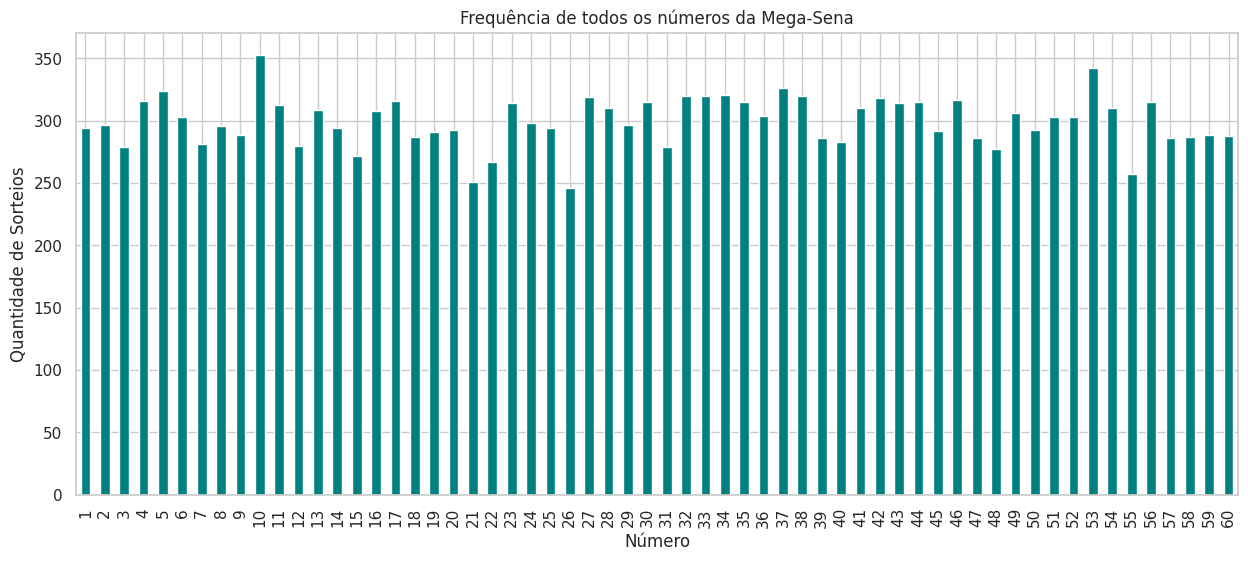

In [7]:
# quantidade de vezes que cada número foi sorteado ao longo do período de análise deste dataset

plt.figure(figsize=(15, 6))
frequencia.plot(kind='bar', color='teal')
plt.title('Frequência de todos os números da Mega-Sena')
plt.xlabel('Número')
plt.ylabel('Quantidade de Sorteios')
plt.show()

In [20]:
# Download do arquivo .CSV contendo a quantidade de vezes que cada numero foi sorteado de acordo com o dataset

resumo_numeros = pd.DataFrame(frequencia)
resumo_numeros = resumo_numeros.reset_index()
resumo_numeros.columns = ['Numero', 'Frequencia_Total']

# 1. Exportar o DataFrame para um arquivo CSV
resumo_numeros.to_csv('resumo_estrategico_mega.csv', index=False, sep=';', encoding='utf-8-sig')

files.download('resumo_estrategico_mega.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1030/203374353.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_6.index, y=top_6.values, palette="magma")


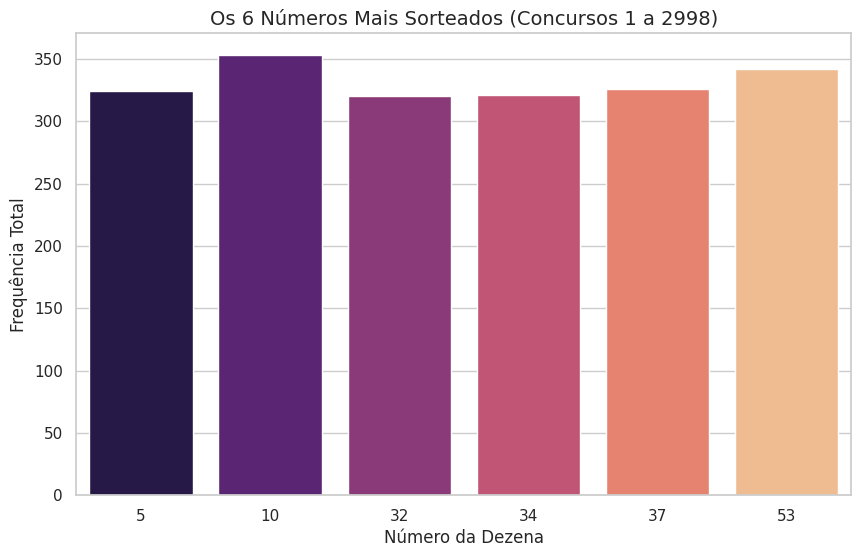

In [9]:
from itertools import combinations
from collections import Counter
import io


# --- MISSÃO 1: O TOP 6 HISTÓRICO ---

todos_os_numeros = df[colunas_bolas].values.flatten()
top_6 = pd.Series(todos_os_numeros).value_counts().head(6)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_6.index, y=top_6.values, palette="magma")

plt.title('Os 6 Números Mais Sorteados (Concursos 1 a 2998)', fontsize=14)
plt.xlabel('Número da Dezena')
plt.ylabel('Frequência Total')
plt.show()



In [10]:
# --- MISSÃO 2: DUPLAS QUE MAIS SAÍRAM JUNTAS ---

todas_as_duplas = []

for sorteio in df[colunas_bolas].values:
    # Geração as combinações de 2 números para cada sorteio
    # sorted() garante que a dupla (5, 10) seja igual a (10, 5)
    duplas = list(combinations(sorted(sorteio), 2))
    todas_as_duplas.extend(duplas)

# Contagem da recorrência das duplas
contagem_duplas = Counter(todas_as_duplas)
mais_comuns = contagem_duplas.most_common(10)

print("\n--- ANALISE DE PROXIMIDADE ---")
print("As 10 duplas que mais apareceram no mesmo bilhete:")
for dupla, qtd in mais_comuns:
    print(f"Os números {dupla[0]} e {dupla[1]} saíram juntos {qtd} vezes.")


--- ANALISE DE PROXIMIDADE ---
As 10 duplas que mais apareceram no mesmo bilhete:
Os números 5 e 27 saíram juntos 41 vezes.
Os números 38 e 53 saíram juntos 41 vezes.
Os números 23 e 53 saíram juntos 41 vezes.
Os números 36 e 53 saíram juntos 41 vezes.
Os números 4 e 52 saíram juntos 40 vezes.
Os números 5 e 11 saíram juntos 40 vezes.
Os números 41 e 53 saíram juntos 40 vezes.
Os números 41 e 58 saíram juntos 40 vezes.
Os números 10 e 33 saíram juntos 40 vezes.
Os números 6 e 34 saíram juntos 39 vezes.


In [11]:
# --- MISSÃO 3: TRIOS QUE MAIS SAIRAM JUNTOS EM FORMATO DE TABELA ---

from itertools import combinations
from collections import Counter
import pandas as pd

todas_as_combinacoes_trio = []

for sorteio in df[colunas_bolas].values:
    trios = list(combinations(sorted(sorteio), 3))
    todas_as_combinacoes_trio.extend(trios)

contagem_trios = Counter(todas_as_combinacoes_trio)
trios_mais_comuns = contagem_trios.most_common(10)

df_trios = pd.DataFrame(trios_mais_comuns, columns=['Trio', 'Frequência'])

# Exibição em estilo tabela no Google Colab.
df_trios

,Trio,Frequência
0,"(9, 41, 49)",8
1,"(5, 24, 25)",8
2,"(29, 38, 50)",8
3,"(24, 25, 42)",8
4,"(6, 11, 40)",8
5,"(4, 52, 56)",8
6,"(29, 32, 38)",8
7,"(8, 11, 39)",8
8,"(10, 32, 49)",8
9,"(4, 28, 30)",8


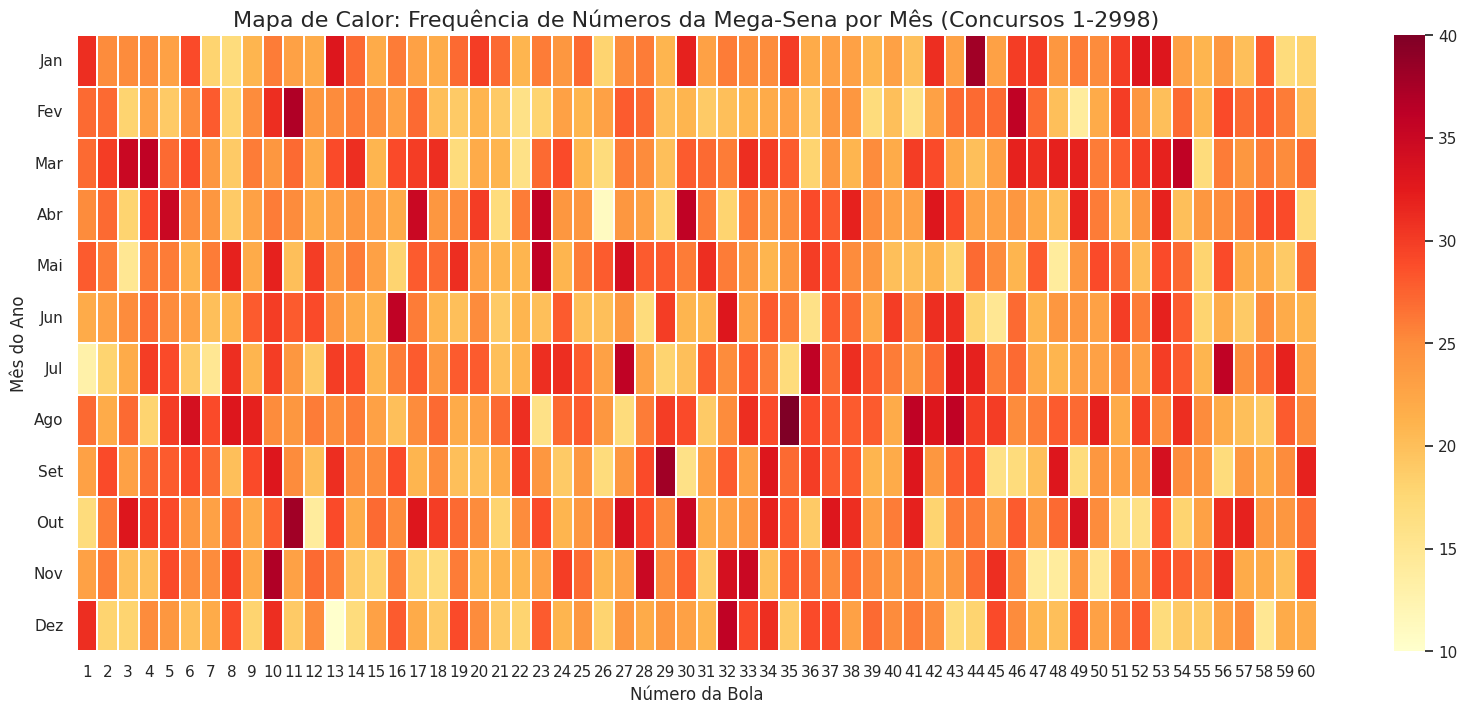

In [17]:
# --- MISSÃO 4: MAPA DE CALOR ---
# Frequência dos numeros mais sorteados na historia da Mega-Sena com base nos meses do ano.

df['Data do Sorteio'] = pd.to_datetime(df['Data do Sorteio'], dayfirst=True)
df['Mes'] = df['Data do Sorteio'].dt.month
df_longo = df.melt(id_vars=['Mes'], value_vars=colunas_bolas, value_name='Numero')

frequencia_mensal = df_longo.groupby(['Mes', 'Numero']).size().unstack(fill_value=0)


plt.figure(figsize=(20, 8))

sns.heatmap(frequencia_mensal, cmap='YlOrRd', linewidths=0.1)

plt.title('Mapa de Calor: Frequência de Números da Mega-Sena por Mês (Concursos 1-2998)', fontsize=16)
plt.xlabel('Número da Bola', fontsize=12)
plt.ylabel('Mês do Ano', fontsize=12)
plt.yticks(ticks=[i + 0.5 for i in range(12)], labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'], rotation=0)

plt.show()